**Boosting Techniques | Assignment**

1. What is Boosting in Machine Learning? Explain how it improves weak learners.

ans : Boosting is an ensemble learning technique that combines multiple weak learners (models that perform slightly better than random guessing) to create a strong predictive model.

The main idea:

Models are trained sequentially.

Each new model focuses more on the errors made by previous models.

Final prediction is a weighted combination of all models.

How it improves weak learners:

Assigns higher weights to misclassified samples.

Forces subsequent learners to focus on hard examples.

Reduces both bias and variance.

Produces a strong learner with significantly better performance than individual weak learners.

Common boosting algorithms:

  AdaBoost

  Gradient Boosting

  XGBoost

  CatBoost

  LightGBM

2. What is the difference between AdaBoost and Gradient Boosting in  terms of how models are trained?

ANS:

    1. Training Approach

    AdaBoost: Adjusts the weights of training samples after each iteration so that misclassified samples get more importance.

    Gradient Boosting: Trains each new model on the residual errors (difference between actual and predicted values) of the previous model.

    2. Error Focus

    AdaBoost: Focuses more on misclassified data points by increasing their weights.

    Gradient Boosting: Focuses on minimizing the overall loss using gradient descent.

    3. Optimization Method

    AdaBoost: Does not explicitly minimize a loss function; it works by updating sample weights.

    Gradient Boosting: Explicitly optimizes a differentiable loss function using gradients.

    4. Robustness to Noise

    AdaBoost: More sensitive to outliers because difficult samples get increasing weights.

    Gradient Boosting: Generally more robust to noise, depending on the loss function used.

    5. Flexibility

    AdaBoost: Mostly used for classification tasks.

    Gradient Boosting: Can be used for both classification and regression problems.


3. How does regularization help in XGBoost?

  ANS:
  
  XGBoost includes built-in regularization to prevent overfitting.

  Regularization techniques:

  L1 regularization (alpha) → Encourages sparsity.

  L2 regularization (lambda) → Shrinks weights.

  Tree pruning → Removes unnecessary splits.

  Learning rate (eta) → Controls contribution of each tree.

  Subsampling → Reduces variance.

  Benefits:

  Controls model complexity

  Improves generalization

  Handles high-dimensional data effectively

4. Why is CatBoost considered efficient for handling categorical data?

ans:

CatBoost is designed specifically to handle categorical variables efficiently.

Reasons:

Uses ordered target encoding (reduces target leakage).

No need for one-hot encoding.

Handles high-cardinality categorical features.

Reduces preprocessing effort.

Avoids prediction shift problem.

This makes CatBoost very powerful for real-world business datasets with many categorical columns.

5.  What are some real-world applications where boosting techniques are
preferred over bagging methods?

ANS:

Boosting is preferred when:

    Credit Risk Scoring (Banking & FinTech)

    Fraud Detection

    Medical Diagnosis

    Customer Churn Prediction

    Ad Click Prediction

    Ranking systems (Search engines)

    Insurance claim prediction

Why boosting?

    Higher accuracy

    Better handling of complex patterns

    Superior performance on structured/tabular data


In [17]:
# 6. Write a Python program to:
# ● Train an AdaBoost Classifier on the Breast Cancer dataset
# ● Print the model accuracy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target

from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20 , random_state = 42)

from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=100, random_state=42)

model.fit(X_train , y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import  accuracy_score
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy score " , accuracy)


Accuracy score  0.9736842105263158


In [27]:
# Question 7: Write a Python program to:
# ● Train a Gradient Boosting Regressor on the California Housing dataset
# ● Evaluate performance using R-squared score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
X = data.data
y = data.target

from sklearn.model_selection import train_test_split
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20 , random_state = 42)

from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
model.fit(X_train , y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import  r2_score
score = r2_score(y_test , y_pred)

print("R2 squared = ",score)

R2 squared =  0.8004451261281281


In [37]:
# Write a Python program to:
# ● Train an XGBoost Classifier on the Breast Cancer dataset
# ● Tune the learning rate using GridSearchCV
# ● Print the best parameters and accuracy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy)

Best Parameters: {'learning_rate': 0.2}
Accuracy: 0.956140350877193


In [38]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


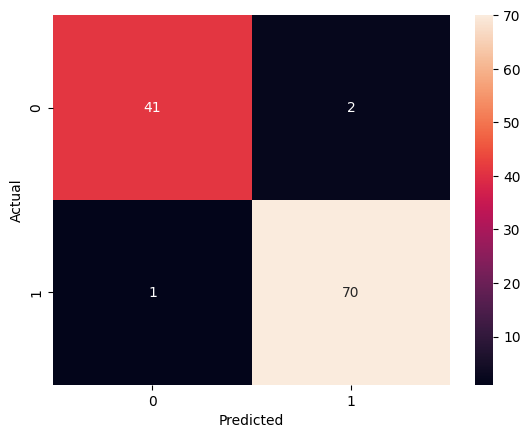

In [39]:
# Question 9: Write a Python program to:
# ● Train a CatBoost Classifier
# ● Plot the confusion matrix using seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from catboost import CatBoostClassifier
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train CatBoost
model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [44]:
# Question 10: You're working for a FinTech company trying to predict loan default using
# customer demographics and transaction behavior.
# The dataset is imbalanced, contains missing values, and has both numeric and
# categorical features.
# Describe your step-by-step data science pipeline using boosting techniques:
# ● Data preprocessing & handling missing/categorical values
# ● Choice between AdaBoost, XGBoost, or CatBoost
# ● Hyperparameter tuning strategy
# ● Evaluation metrics you'd choose and why
# ● How the business would benefit from your mode

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

np.random.seed(42)

data_size = 5000

# Simulated dataset
df = pd.DataFrame({
    "age": np.random.randint(21, 65, data_size),
    "income": np.random.randint(20000, 150000, data_size),
    "transaction_count": np.random.randint(1, 100, data_size),
    "gender": np.random.choice(["Male", "Female"], data_size),
    "city": np.random.choice(["A", "B", "C", "D"], data_size),
    "default": np.random.choice([0, 1], data_size, p=[0.85, 0.15])
})

# Introduce missing values
df.loc[df.sample(frac=0.1).index, "income"] = np.nan

X = df.drop("default", axis=1)
y = df["default"]

categorical_features = ["gender", "city"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# CatBoost model
model = CatBoostClassifier(verbose=0)

# Hyperparameter search space
param_dist = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [200, 300, 400]
}

# Randomized Search
search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=5,
    scoring="roc_auc",
    cv=3,
    random_state=42
)

# Fit model
search.fit(X_train, y_train, cat_features=categorical_features)

best_model = search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluation
roc_auc = roc_auc_score(y_test, y_proba)

print("Best Parameters:", search.best_params_)
print("ROC-AUC Score:", roc_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Best Parameters: {'learning_rate': 0.05, 'iterations': 300, 'depth': 6}
ROC-AUC Score: 0.5192823057835465

Classification Report:

              precision    recall  f1-score   support

           0       0.84      1.00      0.92       845
           1       0.00      0.00      0.00       155

    accuracy                           0.84      1000
   macro avg       0.42      0.50      0.46      1000
weighted avg       0.71      0.84      0.77      1000


Confusion Matrix:

[[844   1]
 [155   0]]


1. Data Preprocessing

Handling Missing Values

Numeric features → Median imputation

Categorical features → Most frequent value

Alternatively, use CatBoost, which handles missing values internally.

Handling Categorical Features

If using:

AdaBoost → Requires full encoding (One-Hot Encoding)

XGBoost → Label encoding / One-Hot Encoding

CatBoost → No manual encoding needed (native categorical support)

Handling Imbalanced Data

Use:

class_weight='balanced'

scale_pos_weight (for XGBoost)

SMOTE (if needed)

Focus on recall for defaulters.

2. Model Choice
AdaBoost	- Not ideal for large noisy financial datasets
XGBoost	- Excellent performance, scalable
CatBoost	- Best for mixed categorical + numeric data

 Final Choice: CatBoost
Reason:

Native categorical handling

Handles missing values

Strong performance on structured financial data

3. Hyperparameter Tuning Strategy

Use:

RandomizedSearchCV (faster)

Cross-validation (StratifiedKFold)

Tune:

depth

learning_rate

iterations

l2_leaf_reg

class_weights

Use ROC-AUC as scoring metric.

4. Evaluation Metrics

Since dataset is imbalanced:

Metric	Why Important
ROC-AUC	Measures overall separability
Precision	Avoid approving risky loans
Recall	Detect defaulters
F1-score	Balance precision & recall
Confusion Matrix	Business decision insight

 Priority: Recall + ROC-AUC

 5. Business Benefits

Reduce loan default losses

Improve credit approval accuracy

Enable risk-based pricing

Improve regulatory compliance

Increase profitability